In [1]:
import sys
import os

project_root = os.path.abspath("..")
sys.path.append(project_root)

In [ ]:
# import getpass
# import os

# if "GROQ_API_KEY" not in os.environ:
#     os.environ["GROQ_API_KEY"] = getpass.getpass("Enter your Groq API key: ")

# from langchain_groq import ChatGroq

# model = ChatGroq(
#     model="qwen/qwen3-32b",
#     temperature=0.7,
#     max_tokens=32000,
#     timeout=None,
#     max_retries=2,
# )

In [ ]:
# import getpass
# import os

# if "GOOGLE_API_KEY" not in os.environ:
#     os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter your Google AI API key: ")

# from langchain_google_genai import ChatGoogleGenerativeAI

# model = ChatGoogleGenerativeAI(
#     model="gemini-flash-latest",
#     temperature=1.0,
#     max_tokens=32000,
#     timeout=None
# )

In [3]:
import getpass
import os

if "ANTHROPIC_API_KEY" not in os.environ:
    os.environ["ANTHROPIC_API_KEY"] = getpass.getpass("Enter your ANTHROPIC_API_KEY: ")

from langchain_anthropic import ChatAnthropic

model = ChatAnthropic(
    model="claude-haiku-4-5-20251001",
    temperature=0.7,
    max_tokens=32000)

/Users/akashb/Library/Caches/pypoetry/virtualenvs/code-gjP0-LuM-py3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
if "TAVILY_API_KEY" not in os.environ:
    os.environ["TAVILY_API_KEY"] = getpass.getpass("Enter your TAVILY_API_KEY: ")

In [5]:
from pydantic import BaseModel, Field
from typing_extensions import Literal

from langgraph.graph import StateGraph, START, END
from langchain_core.messages import SystemMessage, HumanMessage, ToolMessage, filter_messages

from deep_research.state import ResearcherState, ResearcherOutputState
from deep_research.utils import tavily_search, get_today_str, think_tool
from deep_research.prompt import research_system_prompt, compress_research_system_prompt, compress_research_simple_human_message

In [6]:
tools = [tavily_search, think_tool]
tools_by_name = {tool.name: tool for tool in tools}

In [23]:
tools_by_name

{'tavily_search': StructuredTool(name='tavily_search', description='Fetch results from Tavily search API with content summarization.', args_schema=<class 'langchain_core.utils.pydantic.tavily_search'>, func=<function tavily_search at 0x14b9e7420>),
 'think_tool': StructuredTool(name='think_tool', description='Tool for strategic reflection on research progress and decision-making.\n\n    Use this tool after each search to analyze results and plan next steps systematically.\n    This creates a deliberate pause in the research workflow for quality decision-making.\n\n    When to use:\n    - After receiving search results: What key information did I find?\n    - Before deciding next steps: Do I have enough to answer comprehensively?\n    - When assessing research gaps: What specific information am I still missing?\n    - Before concluding research: Can I provide a complete answer now?\n\n    Reflection should address:\n    1. Analysis of current findings - What concrete information have I 

In [7]:
model_with_tools = model.bind_tools(tools)

In [24]:
model_with_tools

RunnableBinding(bound=ChatAnthropic(profile={'name': 'Claude Haiku 4.5', 'release_date': '2025-10-15', 'last_updated': '2025-10-15', 'open_weights': False, 'max_input_tokens': 200000, 'max_output_tokens': 64000, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'pdf_inputs': True, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'structured_output': False}, model='claude-haiku-4-5-20251001', max_tokens=32000, temperature=0.7, anthropic_api_url='https://api.anthropic.com', anthropic_api_key=SecretStr('**********'), model_kwargs={}), kwargs={'tools': [{'name': 'tavily_search', 'input_schema': {'properties': {'query': {'description': 'A single search query to execute', 'type': 'string'}}, 'required': ['query'], 'type': 'object'}, 'descripti

In [8]:
# summarization_model = ChatGoogleGenerativeAI(
#     model="gemini-flash-latest",
#     temperature=1.0,
#     max_tokens=32000,
#     timeout=None
# )

# compress_model = ChatGoogleGenerativeAI(
#     model="gemini-flash-latest",
#     temperature=1.0,
#     max_tokens=32000,
#     timeout=None
# )

summarization_model = ChatAnthropic(
    model="claude-haiku-4-5-20251001",
    temperature=0.7,
    max_tokens=32000)

compress_model = ChatAnthropic(
    model="claude-haiku-4-5-20251001",
    temperature=0.7,
    max_tokens=32000)

In [9]:
def llm_call(state: ResearcherState):
    """Analyze current state and decide on next actions.
    
    The model analyzes the current conversation state and decides whether to:
    1. Call search tools to gather more information
    2. Provide a final answer based on gathered information
    
    Returns updated state with the model's response.
    """
    return {
        "researcher_messages": [
            model_with_tools.invoke(
                [SystemMessage(content=research_system_prompt)] + state["researcher_messages"]
            )
        ]
    }

def tool_node(state: ResearcherState):
    """Execute all tool calls from the previous LLM response.
    
    Executes all tool calls from the previous LLM responses.
    Returns updated state with tool execution results.
    """
    tool_calls = state["researcher_messages"][-1].tool_calls
 
    # Execute all tool calls
    observations = []
    for tool_call in tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observations.append(tool.invoke(tool_call["args"]))
            
    # Create tool message outputs
    tool_outputs = [
        ToolMessage(
            content=observation,
            name=tool_call["name"],
            tool_call_id=tool_call["id"]
        ) for observation, tool_call in zip(observations, tool_calls)
    ]
    
    return {"researcher_messages": tool_outputs}

def compress_research(state: ResearcherState) -> dict:
    """Compress research findings into a concise summary.
    
    Takes all the research messages and tool outputs and creates
    a compressed summary suitable for the supervisor's decision-making.
    """
    
    system_message = compress_research_system_prompt.format(date=get_today_str())
    messages = [SystemMessage(content=system_message)] + state.get("researcher_messages", []) + [HumanMessage(content=compress_research_simple_human_message)]
    response = compress_model.invoke(messages)
    
    # Extract raw notes from tool and AI messages
    raw_notes = [
        str(m.content) for m in filter_messages(
            state["researcher_messages"], 
            include_types=["tool", "ai"]
        )
    ]
    
    return {
        "compressed_research": str(response.content),
        "raw_notes": ["\n".join(raw_notes)]
    }

In [10]:
def should_continue(state: ResearcherState) -> Literal["tool_node", "compress_research"]:
    """Determine whether to continue research or provide final answer.
    
    Determines whether the agent should continue the research loop or provide
    a final answer based on whether the LLM made tool calls.
    
    Returns:
        "tool_node": Continue to tool execution
        "compress_research": Stop and compress research
    """
    messages = state["researcher_messages"]
    last_message = messages[-1]
    
    # If the LLM makes a tool call, continue to tool execution
    if last_message.tool_calls:
        return "tool_node"
    # Otherwise, we have a final answer
    return "compress_research"

In [ ]:
# Build the agent workflow
agent_builder = StateGraph(ResearcherState, output_schema=ResearcherOutputState)

# Add nodes to the graph
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)
agent_builder.add_node("compress_research", compress_research)

# Add edges to connect nodes
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    {
        "tool_node": "tool_node", # Continue research loop
        "compress_research": "compress_research", # Provide final answer
    },
)
agent_builder.add_edge("tool_node", "llm_call") # Loop back for more research
agent_builder.add_edge("compress_research", END)

# Compile the agent
researcher_agent = agent_builder.compile()

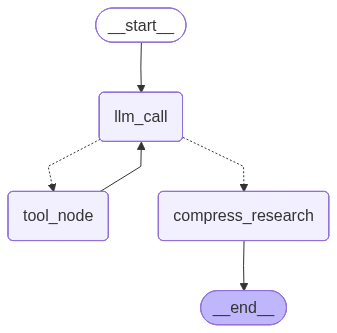

In [12]:
from IPython.display import Image, display

# Show the agent
display(Image(researcher_agent.get_graph(xray=True).draw_mermaid_png()))

In [13]:
from langchain_core.messages import HumanMessage

In [14]:
research_brief = """I want to determine the best Indian Premier League (IPL) team by analyzing two primary metrics: the total number of championship trophies won and the overall win percentage. 
Please research all IPL teams, including defunct ones, from the league's inception in 2008 to the most recently completed season. 
The final output should be a comparative analysis that ranks or lists all teams based on both their total number of IPL titles and their all-time win percentage. 
Please use official sources like the IPL's official website (iplt20.com) or highly reputable sports statistics sites like ESPNcricinfo for data."""

In [15]:
result = researcher_agent.invoke({"researcher_messages": [HumanMessage(content=f"{research_brief}.")]})
result['researcher_messages']

[HumanMessage(content="I want to determine the best Indian Premier League (IPL) team by analyzing two primary metrics: the total number of championship trophies won and the overall win percentage. \nPlease research all IPL teams, including defunct ones, from the league's inception in 2008 to the most recently completed season. \nThe final output should be a comparative analysis that ranks or lists all teams based on both their total number of IPL titles and their all-time win percentage. \nPlease use official sources like the IPL's official website (iplt20.com) or highly reputable sports statistics sites like ESPNcricinfo for data..", additional_kwargs={}, response_metadata={}, id='bffb8256-9f2a-43af-8fa7-553e18b7ffcd'),
 AIMessage(content=[{'text': "I'll help you research and compile comprehensive data on all IPL teams, including their championship wins and overall win percentages. Let me start by gathering this information from official sources.", 'type': 'text'}, {'id': 'toolu_01Qvb

In [21]:
from utils import format_messages

In [22]:
format_messages(result['researcher_messages'])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ I want to determine the best Indian Premier League (IPL) team by analyzing two primary metrics: the total       │
│ number of championship trophies won and the overall win percentage.                                             │
│ Please research all IPL teams, including defunct ones, from the league's inception in 2008 to the most recently │
│ completed season.                                                                                               │
│ The final output should be a comparative analysis that ranks or lists all teams based on both their total       │
│ number of IPL titles and their all-time win percentage.                                                         │
│ Please use official sources like the IPL's official website (iplt20.com) or highly reputable sports statistics  │
│ sites like ESPNcricinfo for data..                                                                              │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ I'll help you research and compile comprehensive data on all IPL teams, including their championship wins and   │
│ overall win percentages. Let me start by gathering this information from official sources.                      │
│                                                                                                                 │
│ 🔧 Tool Call: tavily_search                                                                                     │
│    Args: {                                                                                                      │
│   "query": "IPL teams championship titles winners all time list official"                                       │
│ }                                                                                                               │
│    ID: toolu_01Qvb5rhoz9Ry9MeL7YEvb2a                                                                           │
│                                                                                                                 │
│ 🔧 Tool Call: tavily_search                                                                                     │
│    Args: {                                                                                                      │
│   "query": "IPL all teams win percentage statistics ESPNcricinfo"                                               │
│ }                                                                                                               │
│    ID: toolu_01HpdUDPzoDSMgYdQHn7JXLa                                                                           │
│                                                                                                                 │
│ 🔧 Tool Call: tavily_search                                                                                     │
│    Args: {                                                                                                      │
│   "query": "IPL defunct teams history Rising Pune Supergiants Rajasthan Royals"                                 │
│ }                                                                                                               │
│    ID: toolu_013m7vjys1kQjGG5NW9KshEr                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Search results:                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 1: IPL winners list: Know all champions - Olympics.com ---                                           │
│ URL: https://www.olympics.com/en/news/indian-premier-league-ipl-winners-list-champions                          │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ <summary>                                                                                                       │
│ The Indian Premier League (IPL) is the premier domestic T20 cricket competition in India, organized by the      │
│ Board of Control for Cricket in India (BCCI) since 2008. Currently featuring 10 teams, the IPL has crowned      │
│ eight different champions across 18 editions.                                                                   │
│                                                                                                                 │
│ **Most Successful Teams:**                                                                                      │
│ - Chennai Super Kings and Mumbai Indians are joint-most successful teams with 5 titles each                     │
│ - Chennai Super Kings: Won in 2010, 2011, 2018, 2021, and 2023 under MS Dhoni; finished runners-up 5 times      │
│ (more than any other team)                                                                                      │
│ - Mumbai Indians: Won in 2013, 2015, 2017, 2019, and 2020 under Rohit Sharma; finished runners-up once in 2010  │
│ - Kolkata Knight Riders: 3 titles (2012, 2014, 2024) - the only other team besides CSK and MI with multiple     │
│ wins                                                                                                            │
│                                                                                                                 │
│ **Other Champions:**                                                                                            │
│ - Rajasthan Royals: Inaugural winners in 2008, led by Shane Warne                                               │
│ - Sunrisers Hyderabad: Won in 2016 under David Warner                                                           │
│ - Gujarat Titans: Won in debut season (2022)                                                                    │
│ - Royal Challengers Bengaluru: Ended trophy drought in 2025, defeating Punjab Kings                             │
│ - Deccan Chargers: Won in 2009 (now defunct)                                                                    │
│                                                                                                                 │
│ **Teams Without Titles:**                                                                                       │
│ Punjab Kings and Delhi Capitals are the only active teams that have never won the IPL trophy despite competing  │
│ since the inaugural 2008 season.                                                                                │
│                                                                                                                 │
│ Royal Challengers Bengaluru are the current defending champions (2025).                                         │
│ </summary>                                             

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Search results:                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 1: The IPL in numbers - ESPN ---                                                                     │
│ URL: https://www.espn.com/cricket/story/_/id/22010868/the-ipl-numbers                                           │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ <summary>                                                                                                       │
│ This ESPN Cricinfo article provides comprehensive statistics from the first five editions of the Indian Premier │
│ League (IPL). Key findings include:                                                                             │
│                                                                                                                 │
│ **Overall Tournament Statistics:**                                                                              │
│ - 96,722 total runs scored at an average of 25.61 runs per wicket and 7.89 runs per over                        │
│ - Average 20-over score: 157.71 runs (lowest in 2009 South Africa edition at 149.60; highest in 2010 at 166)    │
│ - 3,086 sixes and 8,555 fours struck (one boundary every 6.32 balls)                                            │
│                                                                                                                 │
│ **Team Performance:**                                                                                           │
│ - Chennai Super Kings: highest team runs (12,736) with 30.18 runs per wicket average                            │
│ - Mumbai Indians: best bowling team with 485 wickets at 22.94 average and 7.34 runs conceded per over           │
│ - Deccan Chargers: lowest batting average at 23.73 runs per wicket but won 2009 title through strong bowling    │
│ (110 wickets)                                                                                                   │
│                                                                                                                 │
│ **Match Dynamics:**                                                                                             │
│ - Teams batting second won 53.87% of matches (174 of 323)                                                       │
│ - Super Kings have highest win percentage batting second (65.52%)                                               │
│ - Fastest scoring occurs in the 20th over (10.46 runs per over); slowest in overs 1 and 7                       │
│ - 15 instances of teams winning off the last ball; 4 one-run victories; 2 tied matches                          │
│                                                                                                                 │
│ **Notable Records:**                                                                                            │
│ - MA Chidambaram Stadium (Chennai): 9,920 runs at 26.31 average                                                 │
│ - Royal Challengers: 59% of runs come from boundaries (6,506 runs)                                              │
│ - Super Kings: most sixes (449) and fours (1,075)                                                               │
│ - Gautam Gambhir: best captain win-loss ratio (1.61); M

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Search results:                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 1: With teams getting defunct and names being changed, where is the ... ---                          │
│ URL:                                                                                                            │
│ https://medium.com/@amankumar_3943/with-teams-getting-defunct-and-names-being-changed-where-is-the-legacy-of-ip │
│ l-teams-heading-c1368c2b13e3                                                                                    │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ Same is the case for Rajasthan Royals playing ... These two suspended teams were replaced by Rising Pune        │
│ SuperGiants, and Gujarat Lions.                                                                                 │
│                                                                                                                 │
│ --------------------------------------------------------------------------------                                │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 2: Gone but not forgotten: 5 defunct IPL franchises and how their journey in the cash-rich league    │
│ panned out ---                                                                                                  │
│ URL:                                                                                                            │
│ https://www.bhaskarenglish.in/sports/cricket/news/5-defunct-ipl-franchises-and-how-their-journey-in-the-cash-ri │
│ ch-league-panned-out-rising-pune-super-giant-gujarat-lions-134656613.html                                       │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ <summary>                                                                                                       │
│ The webpage is a news article from Bhaskar English discussing five defunct IPL (Indian Premier League)          │
│ franchises and their history in the cash-rich cricket league. As IPL 2025 approaches, the article provides a    │
│ retrospective look at teams that failed to survive in the league.                                               │
│                                                                                                                 │
│ **The Five Defunct IPL Teams:**                                                                                 │
│                                                                                                                 │
│ 1. **Pune Warriors India** - Owned by the Sahara Group, operated for three years with players like Yuvraj Singh │
│ and Sourav Ganguly. Despite featuring notable players like Robin Uthappa and Angelo Mathews, they never         │
│ qualified for the playoffs.                                                                                     │
│                                                        

...

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: tavily_search                                                                                     │
│    Args: {                                                                                                      │
│   "query": "IPL teams complete statistics wins losses all franchises Mumbai Indians Kolkata Knight Riders       │
│ Rajasthan Royals 2025"                                                                                          │
│ }                                                                                                               │
│    ID: toolu_01DydjNTmNV7Ph8Jv36mJmme                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Search results:                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 1: IPL 2026 Points Table: IPL Team Standings, IPL Rankings and Net ... ---                           │
│ URL: https://timesofindia.indiatimes.com/sports/cricket/ipl/points-table                                        │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ <summary>                                                                                                       │
│ IPL 2026 Points Table Overview:                                                                                 │
│                                                                                                                 │
│ The IPL 2026 points table tracks team standings and rankings during the league stage. As of the latest update,  │
│ the table shows the current status of all 10 teams based on matches played, wins, losses, and net run rate      │
│ (NRR).                                                                                                          │
│                                                                                                                 │
│ **Current Standings:**                                                                                          │
│ 1. **Rajasthan Royals** - 8 points (4 wins from 5 matches, NRR: +0.889)                                         │
│ 2. **Punjab Kings** - 7 points (3 wins from 4 matches, NRR: +0.720)                                             │
│ 3. **Royal Challengers Bengaluru** - 6 points (3 wins from 4 matches, NRR: +1.148)                              │
│ 4. **Sunrisers Hyderabad** - 4 points (2 wins from 5 matches, NRR: +0.576)                                      │
│ 5. **Delhi Capitals** - 4 points (2 wins from 4 matches, NRR: +0.322)                                           │
│ 6. **Gujarat Titans** - 4 points (2 wins from 4 matches, NRR: -0.029)                                           │
│ 7. **Lucknow Super Giants** - 4 points (2 wins from 4 matches, NRR: -0.427)                                     │
│ 8. **Chennai Super Kings** - 4 points (2 wins from 5 matches, NRR: -0.846) - Recently defeated Kolkata Knight   │
│ Riders by 32 runs                                                                                               │
│ 9. **Mumbai Indians** - 2 points (1 win from 4 matches, NRR: -0.772)                                            │
│ 10. **Kolkata Knight Riders** - 1 point (0 wins from 5 matches, NRR: -1.383) - Struggling with four losses and  │
│ one no result                                                                                                   │
│                                                                                                                 │
│ **Scoring System:**                                                                                             │
│ - Win: 2 points                                                                                                 │
│ - No Result/Abandoned match: 1 point each                                                                       │
│ - Loss: 0 points                                                                                                │
│ - No tied matches (Super Over determines winner, winner

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│ 🔧 Tool Call: think_tool                                                                                        │
│    Args: {                                                                                                      │
│   "reflection": "\nFINAL ASSESSMENT:\n\n1. **Championship Titles (Confirmed from Official IPL Website -         │
│ iplt20.com):**\n   - Mumbai Indians: 5 titles\n   - Chennai Super Kings: 5 titles\n   - Kolkata Knight Riders:  │
│ 3 titles\n   - Rajasthan Royals: 1 title\n   - Sunrisers Hyderabad: 1 title\n   - Gujarat Titans: 1 title\n   - │
│ Royal Challengers Bengaluru: 1 title\n   - Delhi Capitals: 0 titles\n   - Punjab Kings: 0 titles\n   - Lucknow  │
│ Super Giants: 0 titles\n   - Deccan Chargers (Defunct): 1 title (2009)\n\n2. **Win Percentage Data              │
│ Collected:**\n   - CSK: 145 wins in 259 matches = 55.98% (myKhel, recent)\n   - Earlier data from 2019: CSK     │
│ 61.88%, MI 56.83%, SRH 54.29%\n   - Times of India mentions top team with 154 wins (likely CSK through          │
│ 2025)\n\n3. **Defunct Teams Identified:**\n   - Deccan Chargers (2008-2012): Won 2009 title\n   - Kochi Tuskers │
│ Kerala (2011-2012)\n   - Pune Warriors India (2011-2013)\n   - Gujarat Lions (2016-2017)\n   - Rising Pune      │
│ Supergiants (2016-2017)\n\n4. **Data Limitations:**\n   - I have used 5 search calls (my maximum)\n   - I have  │
│ championship data from official IPL website\n   - I have partial win percentage data (CSK clearly, others less  │
│ clear)\n   - ESPNcricinfo pages mentioned but summaries didn't provide complete team-by-team stats\n   -        │
│ Complete all-time win percentages for every team not fully available in searches\n\n5. **DECISION:**\n   - I    │
│ have sufficient data for a comprehensive comparative analysis\n   - Championship data is verified from official │
│ source (iplt20.com)\n   - Win percentage data is available for some teams with recent statistics\n   - I should │
│ provide the analysis with clear sourcing and note data limitations where they exist\n   - The analysis can be   │
│ organized by both metrics as requested\n"                                                                       │
│ }                                                                                                               │
│    ID: toolu_01HxBvayaaTiREU67vGfk7RZ                                                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Reflection recorded:                                                                                            │
│ FINAL ASSESSMENT:                                                                                               │
│                                                                                                                 │
│ 1. **Championship Titles (Confirmed from Official IPL Website - iplt20.com):**                                  │
│    - Mumbai Indians: 5 titles                                                                                   │
│    - Chennai Super Kings: 5 titles                                                                              │
│    - Kolkata Knight Riders: 3 titles                                                                            │
│    - Rajasthan Royals: 1 title                                                                                  │
│    - Sunrisers Hyderabad: 1 title                                                                               │
│    - Gujarat Titans: 1 title                                                                                    │
│    - Royal Challengers Bengaluru: 1 title                                                                       │
│    - Delhi Capitals: 0 titles                                                                                   │
│    - Punjab Kings: 0 titles                                                                                     │
│    - Lucknow Super Giants: 0 titles                                                                             │
│    - Deccan Chargers (Defunct): 1 title (2009)                                                                  │
│                                                                                                                 │
│ 2. **Win Percentage Data Collected:**                                                                           │
│    - CSK: 145 wins in 259 matches = 55.98% (myKhel, recent)                                                     │
│    - Earlier data from 2019: CSK 61.88%, MI 56.83%, SRH 54.29%                                                  │
│    - Times of India mentions top team with 154 wins (likely CSK through 2025)                                   │
│                                                                                                                 │
│ 3. **Defunct Teams Identified:**                                                                                │
│    - Deccan Chargers (2008-2012): Won 2009 title                                                                │
│    - Kochi Tuskers Kerala (2011-2012)                                                                           │
│    - Pune Warriors India (2011-2013)                                                                            │
│    - Gujarat Lions (2016-2017)                                                                                  │
│    - Rising Pune Supergiants (2016-2017)                                                                        │
│                                                                                                                 │
│ 4. **Data Limitations:**                                                                                        │
│    - I have used 5 search calls (my maximum)                                                                    │
│    - I have championship data from official IPL website                                                         │
│    - I have partial win percentage data (CSK clearly, others less clear)                                        │
│    - ESPNcricinfo pages mentioned but summaries didn't provide complete team-by-team stats                      │
│    - Complete all-time win percentages for every team n

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ ---                                                                                                             │
│                                                                                                                 │
│ ## **COMPREHENSIVE IPL TEAM ANALYSIS: CHAMPIONSHIP TITLES & WIN PERCENTAGES**                                   │
│                                                                                                                 │
│ Based on my research from official sources including **iplt20.com** (official IPL website), **ESPNcricinfo**,   │
│ **myKhel**, and other reputable sports statistics platforms, here is a detailed comparative analysis of all IPL │
│ teams from 2008 to the 2025 season.                                                                             │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ ## **PART 1: RANKING BY IPL CHAMPIONSHIP TITLES**                                                               │
│                                                                                                                 │
│ ### **Tier 1: Most Successful (5 Titles Each)**                                                                 │
│                                                                                                                 │
│ | **Rank** | **Team** | **Titles** | **Championship Years** |                                                   │
│ |----------|----------|-----------|----------------------|                                                      │
│ | 1 | **Mumbai Indians** | 5 | 2013, 2015, 2017, 2019, 2020 |                                                   │
│ | 1 | **Chennai Super Kings** | 5 | 2010, 2011, 2018, 2021, 2023 |                                              │
│                                                                                                                 │
│ **Key Insights:**                                                                                               │
│ - Mumbai Indians and Chennai Super Kings are joint-most successful IPL franchises                               │
│ - Combined, they account for **10 out of 18 IPL titles** (55.6% of all championships)                           │
│ - **Rohit Sharma** (MI captain) and **MS Dhoni** (CSK captain) are tied as most successful captains with 5      │
│ titles each                                                                                                     │
│ - CSK holds the record for most finals appearances with **10 finals** (5 wins, 5 runner-up finishes)            │
│ - MI has the best finals conversion rate at **83.33%** (5 wins from 6 finals appearances)                       │
│                                                                                                                 │
│ ---                                                                                                             │
│                                                                                                                 │
│ ### **Tier 2: Multiple Titles (3 Titles)**                                                                      │
│                                                                                                                 │
│ | **Rank** | **Team** | **Titles** | **Championship Years** |                                                   │
│ |----------|----------|-----------|----------------------|                                                      │
│ | 3 | **Kolkata Knight Riders** | 3 | 2012, 2014, 2024 